# Count the number of colocalization points in the Mediterranean sea
## What is done here ?
- select the drifters points under the swaths for each cycle considering drifters points for which it is the nearest swot image (one cycle every 23h50 approximately, e.g drifters in the $\pm$ 12h25 before and after the swot image)
- compute the minimum/maximum time gap for each swot image/cycle (will depend on the dt of the regular grid)

## Results ?
- some cycle are not available :
    - swath 3 : 498, 526-528, 566, 572
    - swath 16 : 480, 508, 513, 526-528, 534

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from rasterio.transform import Affine

import pynsitu as pyn

/Users/mdemol/code/pynsitu/pynsitu/__init__.py:45: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  hour = Timedelta("1H")


_______
# Select under swath drifters - create and store dataset

In [2]:
dfs = browse_swot_250().reset_index()
dfs

,day,pass_number,cycle_number,file,time,start_time_cut,end_time_cut
0,2023-04-01,3,478,/Users/mdemol/DATA_KARIN/L3_250/3_478.zarr,2023-04-01 23:42:32.696536000,2023-04-01 11:47:13.760762624,2023-04-02 11:37:51.561104544
1,2023-04-02,3,479,/Users/mdemol/DATA_KARIN/L3_250/3_479.zarr,2023-04-02 23:33:10.425673088,2023-04-02 11:37:51.561104544,2023-04-03 11:28:29.307429408
2,2023-04-03,3,480,/Users/mdemol/DATA_KARIN/L3_250/3_480.zarr,2023-04-03 23:23:48.189185728,2023-04-03 11:28:29.307429408,2023-04-04 11:19:07.046608544
3,2023-04-04,3,481,/Users/mdemol/DATA_KARIN/L3_250/3_481.zarr,2023-04-04 23:14:25.904031360,2023-04-04 11:19:07.046608544,2023-04-05 11:09:44.780262144
4,2023-04-05,3,482,/Users/mdemol/DATA_KARIN/L3_250/3_482.zarr,2023-04-05 23:05:03.656492928,2023-04-05 11:09:44.780262144,2023-04-06 11:00:22.763027360
...,...,...,...,...,...,...,...
182,2023-07-05,16,573,/Users/mdemol/DATA_KARIN/L3_250/16_573.zarr,2023-07-05 19:33:50.331633280,2023-07-05 07:38:31.368841152,2023-07-06 07:29:09.302501440
183,2023-07-06,16,574,/Users/mdemol/DATA_KARIN/L3_250/16_574.zarr,2023-07-06 19:24:28.273369600,2023-07-06 07:29:09.302501440,2023-07-07 07:19:47.209324384
184,2023-07-07,16,575,/Users/mdemol/DATA_KARIN/L3_250/16_575.zarr,2023-07-07 19:15:06.145279168,2023-07-07 07:19:47.209324384,2023-07-08 07:10:25.074586176
185,2023-07-08,16,576,/Users/mdemol/DATA_KARIN/L3_250/16_576.zarr,2023-07-08 19:05:44.003893184,2023-07-08 07:10:25.074586176,2023-07-09 07:01:02.936174400


In [3]:
drifters_sources = 'all_med_variational_10min_v0.nc'
dr = xr.open_dataset(os.path.join(drifters_dir,'L2', 'all_med_variational_10min_v0.nc'))
dr_key = dr[['cruise_id', 'drifter_type']]
dr = dr.where(dr.gap_mask==1)

In [4]:
dr

<xarray.Dataset> Size: 612MB
Dimensions:             (drifter_id: 162, datetime: 27786)
Coordinates:
  * datetime            (datetime) datetime64[ns] 222kB 2023-03-27T13:10:00 ....
  * drifter_id          (drifter_id) <U15 10kB '4388938' '4694122' ... '4694474'
Data variables: (12/17)
    x                   (drifter_id, datetime) float64 36MB nan nan ... nan nan
    y                   (drifter_id, datetime) float64 36MB nan nan ... nan nan
    drifter_type        (drifter_id, datetime) object 36MB nan nan ... nan nan
    cruise_id           (drifter_id, datetime) object 36MB nan nan ... nan nan
    lonc                (drifter_id, datetime) float64 36MB nan nan ... nan nan
    latc                (drifter_id, datetime) float64 36MB nan nan ... nan nan
    ...                  ...
    acceleration_east   (drifter_id, datetime) float64 36MB nan nan ... nan nan
    acceleration_north  (drifter_id, datetime) float64 36MB nan nan ... nan nan
    acceleration        (drifter_id, datetime) float64 36MB nan nan ... nan nan
    X                   (drifter_id, datetime) float64 36MB nan nan ... nan nan
    gap_mask            (drifter_id, datetime) float64 36MB nan nan ... nan nan
    gaps                (drifter_id, datetime) float64 36MB nan nan ... nan nan
Attributes:
    description:                     L2 product - applied smoothing method on...
    smoothing_method:                Variational
    smoothing_method_param_dict:     {'acc_cut': 0.001, 'position_error': 70,...
    interpolation_sampling:          10min
    version:                         v0
    geographical_projection:         Asimuthal Equidistant projection centere...
    geographical_projection_pyproj:  pyproj.Proj(proj="aeqd", lat_0=latc, lon...
    citation_str:                    
    distribution_str:                These data were collected and made freel...
    title:                           L2 - Smoothed and regularly interpolated...
    generation_date:                 2024-07-23 11:08:01.858786

In [10]:
drifters_sources = 'all_med_variational_10min_v0.nc'
dr = xr.open_dataset(os.path.join(drifters_dir,'L2', 'all_med_variational_10min_v0.nc'))
dr_key = dr[['cruise_id', 'drifter_type']]
dr = dr.where(dr.gap_mask==1)

def sel_drifters(swath, cycle):
    dfs_ = dfs.where((dfs.pass_number==swath)&(dfs.cycle_number==cycle)).dropna()
    dss = xr.open_dataset(dfs.where((dfs.pass_number==swath)&(dfs.cycle_number==cycle)).dropna().file.values[0])
    
    #time
    dr_ = dr.sel(datetime = slice(pd.to_datetime(dfs_.start_time_cut).values[0], pd.to_datetime(dfs_.end_time_cut).values[0]))
    dr_= add_mask_inside_swot(dss, dr_)
    #under swath
    dr_ = dr_.where(dr_["inside_left"]+dr_["inside_right"])
    dfr_ = dr_.to_dataframe().reset_index().dropna()
    #time to nearest swot
    dfr_['time_to_swot']=(dfr_.datetime-dfs_.time.values[0]).abs()

    # stats for each drifters
    dfrs_=pd.DataFrame()
    dfrs_['time_to_swot_min'] = dfr_.groupby('drifter_id').time_to_swot.min()
    dfrs_['time_to_swot_max'] = dfr_.groupby('drifter_id').time_to_swot.max()
    dfrs_['point_number'] = dfr_.groupby('drifter_id').datetime.count()
    dfrs_['cycle_number'] = int(dfs_.cycle_number.values[0])
    dfrs_['cycle_date'] = dfs_.time.values[0]
    dfrs_['pass_number'] = int(dfs_.pass_number.values[0])
    return dfs_, dfr_, dfrs_.reset_index()


D = []
for swath in [3,16]:
    for cycle in dfs.where(dfs.pass_number==swath).dropna().cycle_number:
        dfs_, dfr_, dfrs_ = sel_drifters(swath, cycle)
        dfr_['cycle_number'] = int(dfs_.cycle_number.values[0])
        dfr_['cycle_date'] = dfs_.time.values[0]
        dfr_['pass_number'] = int(dfs_.pass_number.values[0])
        #D.append(dfr_.loc[dfr_.groupby(['drifter_id']).time_to_swot.idxmin()])
        D.append(dfr_)
df = pd.concat(D).set_index('pass_number').reset_index()
df['row_number'] = np.arange(len(df))
df = df.set_index('row_number')
df.to_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails wh

In [6]:
# EXAMPLE
dfs_, dfr_, dfrs_ = sel_drifters(3, 500)

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


In [7]:
D = []
for swath in [3,16]:
    for cycle in dfs.where(dfs.pass_number==swath).dropna().cycle_number:
        dfs_, dfr_, dfrs_ = sel_drifters(swath, cycle)
        D.append(dfrs_)
df_stats = pd.concat(D)
df_stats.to_csv(os.path.join(zarr_dir, 'drifters_stats_'+drifters_sources.replace('.nc', '.csv')))

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails wh

In [11]:
dfc = df.loc[df.groupby(['drifter_id', 'cycle_number']).time_to_swot.idxmin()]

In [12]:
dfc

,pass_number,drifter_id,datetime,x,y,drifter_type,cruise_id,lonc,latc,longitude,...,acceleration_north,acceleration,X,gap_mask,gaps,inside_left,inside_right,time_to_swot,cycle_number,cycle_date
row_number,,,,,,,,,,,,,,,,,,,,,
214,3,0-4351296,2023-04-01 23:40:00,8622.832328,21924.659043,CARTHE,C-SWOT,5.527754,42.057971,5.632249,...,-0.000023,0.000028,23559.369930,1.0,-207.0,0.0,1.0,0 days 00:02:32.696536,478,2023-04-01 23:42:32.696536000
1268,3,0-4351296,2023-04-02 23:30:00,5714.599768,-2884.880690,CARTHE,C-SWOT,5.527754,42.057971,5.596763,...,-0.000002,0.000007,6401.498817,1.0,92.0,0.0,1.0,0 days 00:03:10.425673088,479,2023-04-02 23:33:10.425673088
2354,3,0-4351296,2023-04-03 23:10:00,21208.169637,-18758.333905,CARTHE,C-SWOT,5.527754,42.057971,5.783290,...,-0.000010,0.000011,28313.628348,1.0,79.0,0.0,1.0,0 days 00:13:48.189185728,480,2023-04-03 23:23:48.189185728
3427,3,0-4351296,2023-04-04 23:10:00,13990.134781,-40864.559278,CARTHE,C-SWOT,5.527754,42.057971,5.695799,...,0.000003,0.000003,43193.009575,1.0,-195.0,0.0,1.0,0 days 00:04:25.904031360,481,2023-04-04 23:14:25.904031360
4660,3,0-4351296,2023-04-05 23:10:00,2620.087117,-42045.096546,CARTHE,C-SWOT,5.527754,42.057971,5.559221,...,0.000002,0.000032,42126.654271,1.0,-615.0,0.0,1.0,0 days 00:04:56.343507072,482,2023-04-05 23:05:03.656492928
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89783,3,9,2023-05-01 21:10:00,-34323.350143,-2521.577238,MELODI,C-SWOT,5.161950,41.006110,4.754100,...,-0.000021,0.000025,34415.849791,1.0,0.0,0.0,1.0,0 days 02:08:29.832942336,508,2023-05-01 19:01:30.167057664
93838,3,9,2023-05-02 18:50:00,-28975.193513,-28207.916915,MELODI,C-SWOT,5.161950,41.006110,4.818847,...,0.000022,0.000036,40438.204903,1.0,120.0,0.0,1.0,0 days 00:02:07.908758144,509,2023-05-02 18:52:07.908758144
97597,3,9,2023-05-03 13:30:00,-39181.151155,-22185.668465,MELODI,C-SWOT,5.161950,41.006110,4.697619,...,0.000025,0.000032,45026.286667,1.0,120.0,0.0,1.0,0 days 05:12:45.572310080,510,2023-05-03 18:42:45.572310080


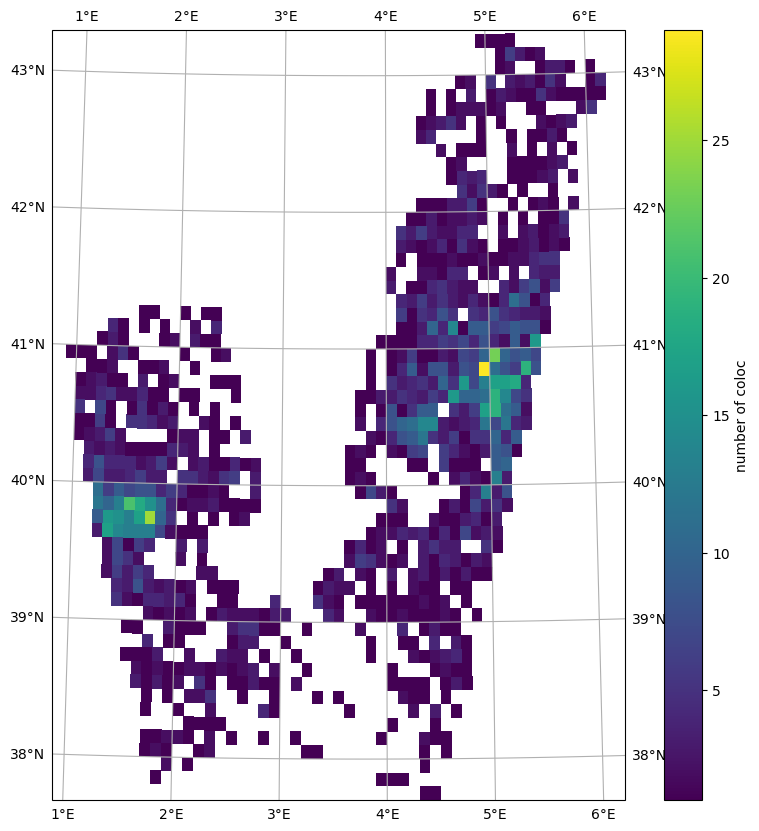

In [16]:
dl = 1/10
dfc["latbin"] = (dfc.latitude // dl) * dl
dfc["lonbin"] = (dfc.longitude // dl) * dl
dd = dfc.groupby(["latbin", "lonbin"]).x.count().to_xarray()
dd.name = 'number of coloc'
dd['lonbin'] = dd['lonbin']+dl/2
dd['latbin'] = dd['latbin']+dl/2


fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection=ccrs.Orthographic(dfc.longitude.mean(), dfc.latitude.mean()))
dd.plot(ax=ax, transform=crs)
gl = ax.gridlines(draw_labels=True,)

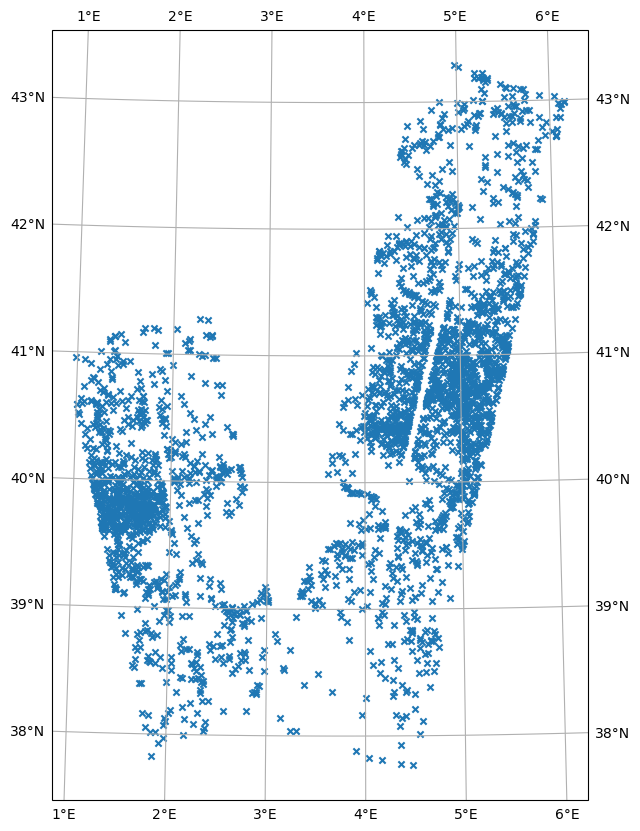

In [17]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection=ccrs.Orthographic(dfc.longitude.mean(), dfc.latitude.mean()))
dfc.plot.scatter(x='longitude', y='latitude',ax=ax, transform=crs, marker='x')
gl = ax.gridlines(draw_labels=True,)